In [ ]:
# Performance summary
print("=" * 70)
print("BENCHMARK SUMMARY")
print("=" * 70)

if 'found_overall_path' in df.columns:
    print("\n1. OVERALL PATH FINDING TIME (seconds)")
    print("-" * 70)
    for algo in sorted(df['algorithm'].unique()):
        algo_times = df[df['algorithm'] == algo]['found_overall_path']
        print(f"\n  {algo.upper()}:")
        print(f"    Mean:   {algo_times.mean():.6f}s")
        print(f"    Median: {algo_times.median():.6f}s")
        print(f"    Std:    {algo_times.std():.6f}s")
        print(f"    Min:    {algo_times.min():.6f}s (cluster size {df[df['algorithm']==algo].loc[algo_times.idxmin(), 'cluster_size']:.0f})")
        print(f"    Max:    {algo_times.max():.6f}s (cluster size {df[df['algorithm']==algo].loc[algo_times.idxmax(), 'cluster_size']:.0f})")

if 'intra cluster pathfinding' in df.columns:
    print("\n2. INTRA CLUSTER PATHFINDING TIME (seconds)")
    print("-" * 70)
    for algo in sorted(df['algorithm'].unique()):
        algo_times = df[df['algorithm'] == algo]['intra cluster pathfinding']
        if algo_times.sum() > 0:  # Only show if not all zeros
            print(f"\n  {algo.upper()}:")
            print(f"    Mean:   {algo_times.mean():.6f}s")
            print(f"    Max:    {algo_times.max():.6f}s")

# Cluster size analysis
print("\n3. PERFORMANCE BY CLUSTER SIZE")
print("-" * 70)
cluster_stats = df.groupby('cluster_size')['found_overall_path'].agg(['mean', 'std', 'count'])
print(f"\n  Fastest cluster size: {cluster_stats['mean'].idxmin()} (avg: {cluster_stats['mean'].min():.6f}s)")
print(f"  Slowest cluster size: {cluster_stats['mean'].idxmax()} (avg: {cluster_stats['mean'].max():.6f}s)")
print(f"  Speedup: {cluster_stats['mean'].max() / cluster_stats['mean'].min():.2f}x")

print("\n" + "=" * 70)

BENCHMARK SUMMARY

1. OVERALL PATH FINDING TIME (seconds)
----------------------------------------------------------------------

  HPA:
    Mean:   0.018151s
    Median: 0.018013s
    Std:    0.000798s
    Min:    0.017805s (cluster size 1)
    Max:    0.025674s (cluster size 300)

2. PREPROCESSING TIME (seconds)
----------------------------------------------------------------------

  HPA:
    Mean:   1.726677s
    Max:    1.945634s

3. PERFORMANCE BY CLUSTER SIZE
----------------------------------------------------------------------

  Fastest cluster size: 1 (avg: 0.017944s)
  Slowest cluster size: 300 (avg: 0.018695s)
  Speedup: 1.04x



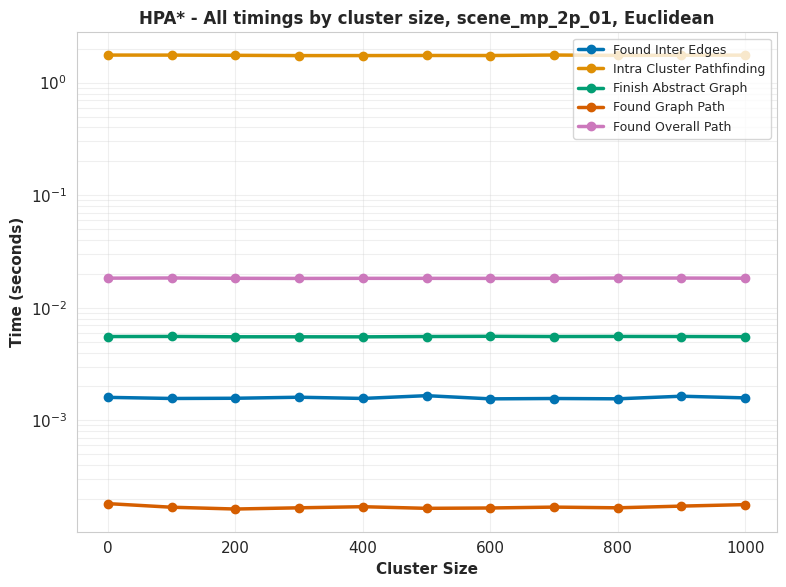

All timing steps plotted with logarithmic scale


In [111]:
# Plot all timing steps for each algorithm on same graph with different colors
timing_metrics = [col for col in df.columns if col not in ['cluster_size', 'algorithm', 'run'] 
                  and 'memory' not in col.lower()]

algorithms = sorted(df['algorithm'].unique())

# Use colorblind-friendly palette
colorblind_palette = sns.color_palette("colorblind", len(timing_metrics))
colors = colorblind_palette

fig, axes = plt.subplots(1, len(algorithms), figsize=(8*len(algorithms), 6))

# Ensure axes is always iterable
if len(algorithms) == 1:
    axes = [axes]

for algo_idx, algo in enumerate(algorithms):
    ax = axes[algo_idx]
    algo_data = df[df['algorithm'] == algo]
    
    for metric_idx, metric in enumerate(timing_metrics):
        # Skip if metric doesn't exist or all zeros
        if metric not in algo_data.columns:
            continue
        
        grouped = algo_data.groupby('cluster_size')[metric].agg(['mean'])
        
        # Skip if all values are zero
        if grouped['mean'].sum() == 0:
            continue
        
        ax.plot(grouped.index, grouped['mean'], marker='o', linewidth=2.5, 
                markersize=6, color=colors[metric_idx], label=metric.replace('_', ' ').title())
    
    ax.set_xlabel('Cluster Size', fontsize=11, fontweight='bold')
    ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title(f'{algo.upper()}* - All timings by cluster size, scene_mp_2p_01, Euclidean', fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("All timing steps plotted with logarithmic scale")

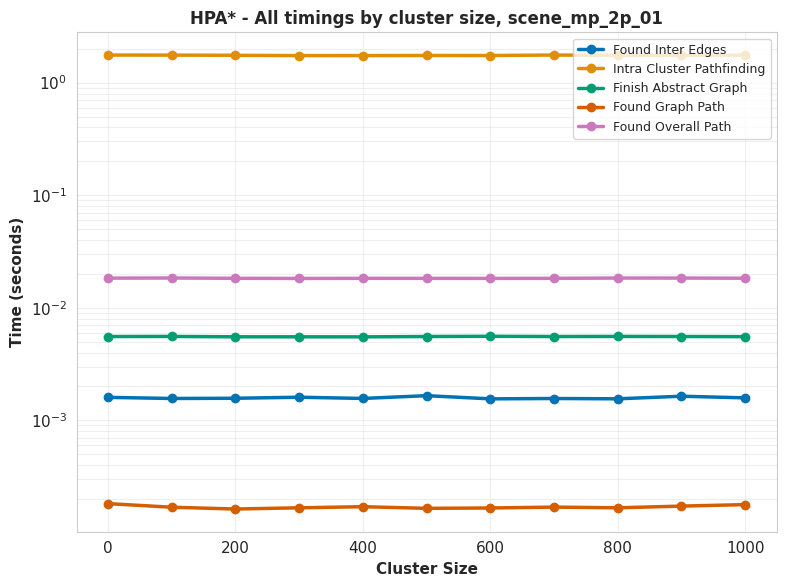

All timing steps plotted with logarithmic scale


In [98]:
# Plot all timing steps for each algorithm on same graph with different colors
timing_metrics = [col for col in df.columns if col not in ['cluster_size', 'algorithm', 'run'] 
                  and 'memory' not in col.lower()]

algorithms = sorted(df['algorithm'].unique())

# Use colorblind-friendly palette
colorblind_palette = sns.color_palette("colorblind", len(timing_metrics))
colors = colorblind_palette

fig, axes = plt.subplots(1, len(algorithms), figsize=(8*len(algorithms), 6))

# Ensure axes is always iterable
if len(algorithms) == 1:
    axes = [axes]

for algo_idx, algo in enumerate(algorithms):
    ax = axes[algo_idx]
    algo_data = df[df['algorithm'] == algo]
    
    for metric_idx, metric in enumerate(timing_metrics):
        # Skip if metric doesn't exist or all zeros
        if metric not in algo_data.columns:
            continue
        
        grouped = algo_data.groupby('cluster_size')[metric].agg(['mean'])
        
        # Skip if all values are zero
        if grouped['mean'].sum() == 0:
            continue
        
        ax.plot(grouped.index, grouped['mean'], marker='o', linewidth=2.5, 
                markersize=6, color=colors[metric_idx], label=metric.replace('_', ' ').title())
    
    ax.set_xlabel('Cluster Size', fontsize=11, fontweight='bold')
    ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title(f'{algo.upper()}* - All timings by cluster size, scene_mp_2p_01', fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("All timing steps plotted with logarithmic scale")

## Memory Usage vs Cluster Size

Analyze memory consumption for each algorithm across different cluster sizes.

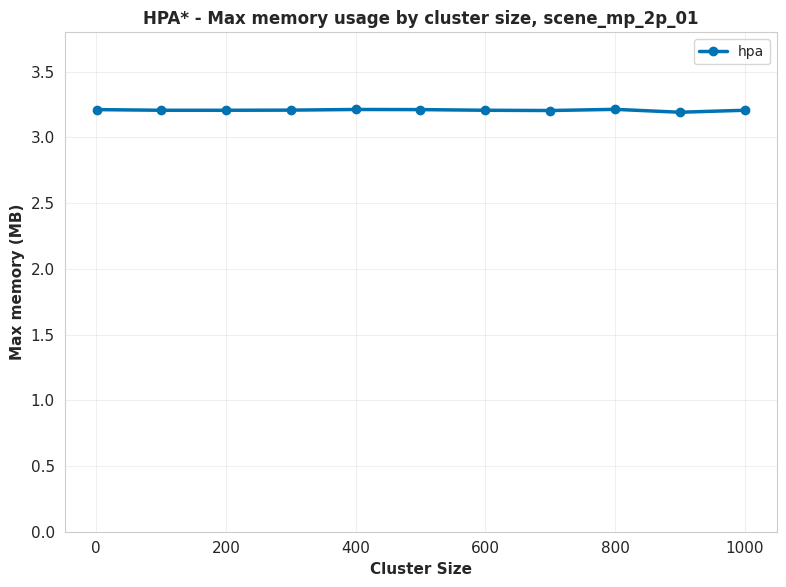

Memory usage plotted for 1 metric(s)


In [112]:

# Plot memory usage metrics
memory_metrics = [col for col in df.columns if 'memory' in col.lower()]

if memory_metrics:
    fig, axes = plt.subplots(1, len(memory_metrics), figsize=(8*len(memory_metrics), 6))
    
    # Ensure axes is always iterable
    if len(memory_metrics) == 1:
        axes = [axes]
    
    for metric_idx, metric in enumerate(memory_metrics):
        ax = axes[metric_idx]
        
        for algo in sorted(df['algorithm'].unique()):
            algo_data = df[df['algorithm'] == algo]
            grouped = algo_data.groupby('cluster_size')[metric].agg(['mean'])
            
            ax.plot(grouped.index, grouped['mean'], marker='o', linewidth=2.5, 
                    markersize=6, label=algo)
        
        ax.set_xlabel('Cluster Size', fontsize=11, fontweight='bold')
        ax.set_ylabel("Max memory (MB)", fontsize=11, fontweight='bold')
        ax.set_title(f'HPA* - Max memory usage by cluster size, scene_mp_2p_01', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 3.8])

    plt.tight_layout()
    plt.show()
    
    print(f"Memory usage plotted for {len(memory_metrics)} metric(s)")
else:
    print("No memory metrics found in the data")

## All Timing Steps Comparison

Plot all timing metrics as line charts to see how each step scales with cluster size.

## Performance Summary

Summary statistics and key insights from the benchmark data.

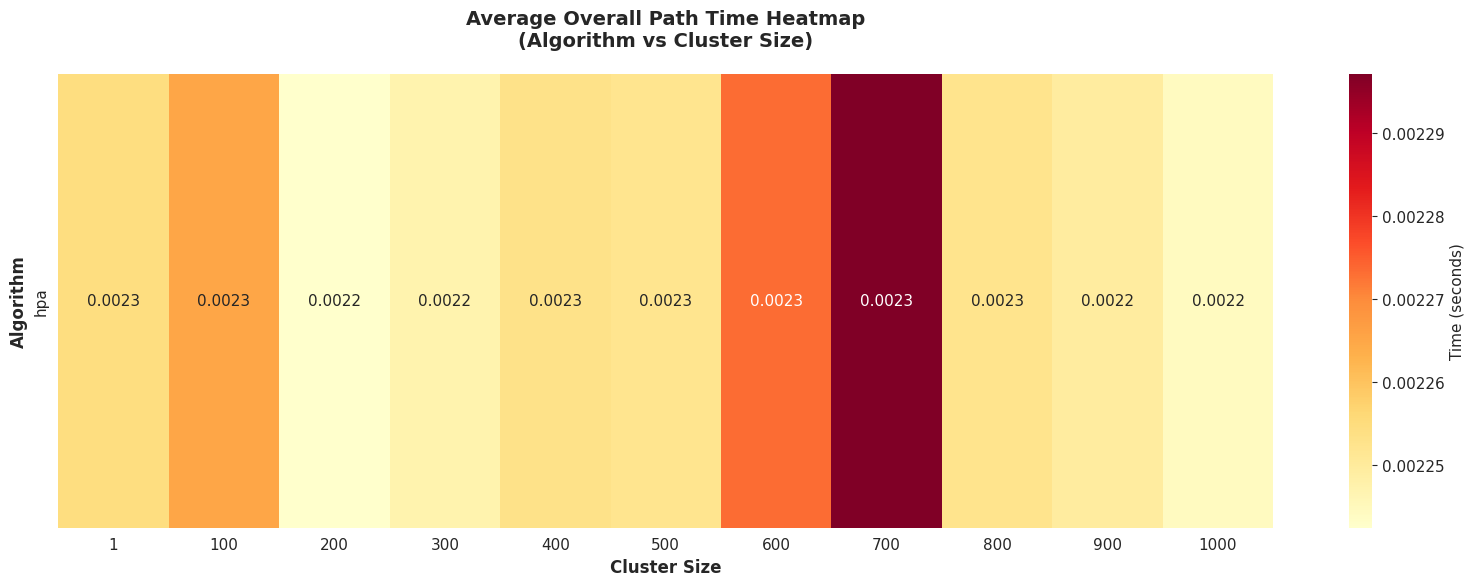

Heatmap generated


In [ ]:
if 'found_overall_path' in df.columns:
    # Create pivot table for heatmap
    pivot_data = df.pivot_table(
        values='found_overall_path',
        index='algorithm',
        columns='cluster_size',
        aggfunc='mean'
    )
    
    fig, ax = plt.subplots(figsize=(16, 6))
    # Use colorblind-friendly colormap (cividis)
    sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='cividis', 
                ax=ax, cbar_kws={'label': 'Time (seconds)'})
    
    ax.set_title('Average Overall Path Time Heatmap\n(Algorithm vs Cluster Size)', 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Cluster Size', fontsize=12, fontweight='bold')
    ax.set_ylabel('Algorithm', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Heatmap generated")

## Export Data

Export results to CSV files for external analysis.

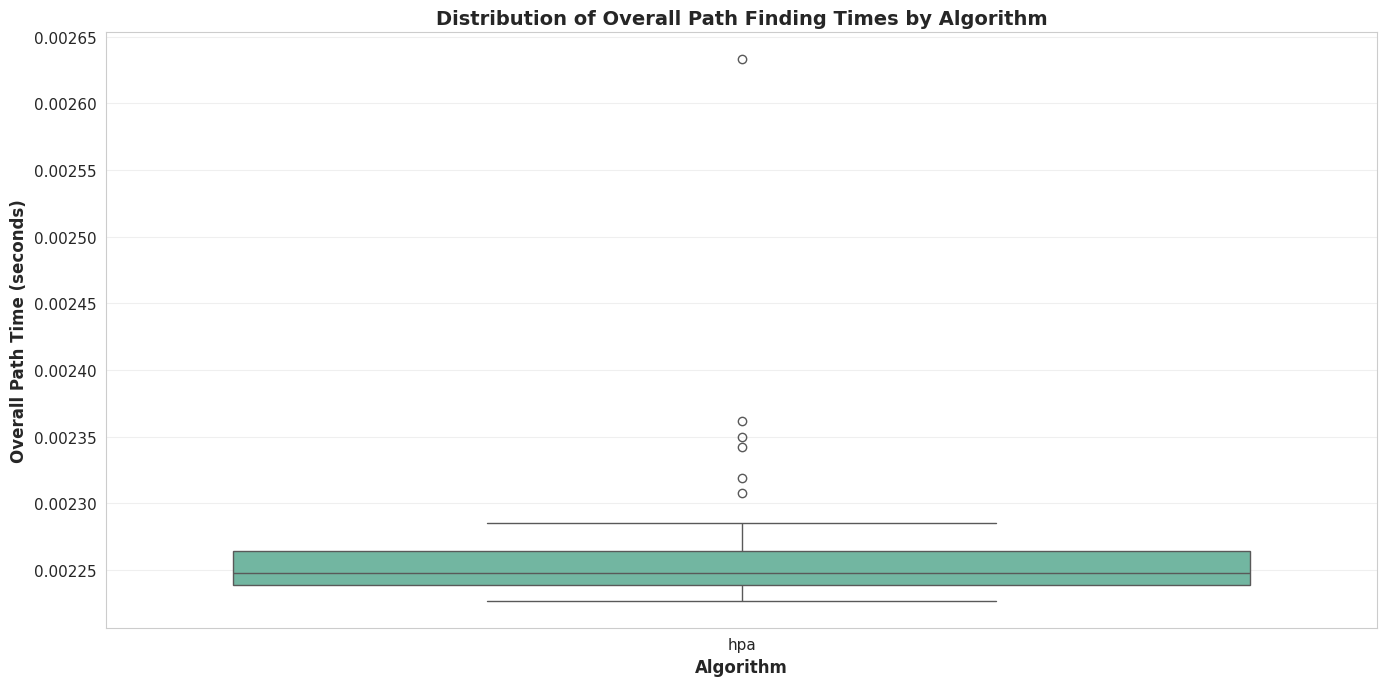


Overall Statistics by Algorithm:
           count      mean       std       min       25%       50%       75%  \
algorithm                                                                      
hpa        110.0  0.002257  0.000043  0.002227  0.002239  0.002247  0.002264   

                max  
algorithm            
hpa        0.002633  


In [ ]:
if 'found_overall_path' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Create box plot by algorithm with colorblind-friendly palette
    sns.boxplot(data=df, x='algorithm', y='found_overall_path', ax=ax, palette='colorblind')
    
    ax.set_xlabel('Algorithm', fontsize=12, fontweight='bold')
    ax.set_ylabel('Overall Path Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_title('Distribution of Overall Path Finding Times by Algorithm', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nOverall Statistics by Algorithm:")
    print(df.groupby('algorithm')['found_overall_path'].describe())

## Distribution Analysis - Box Plots

Show the distribution of times across all runs for each algorithm.

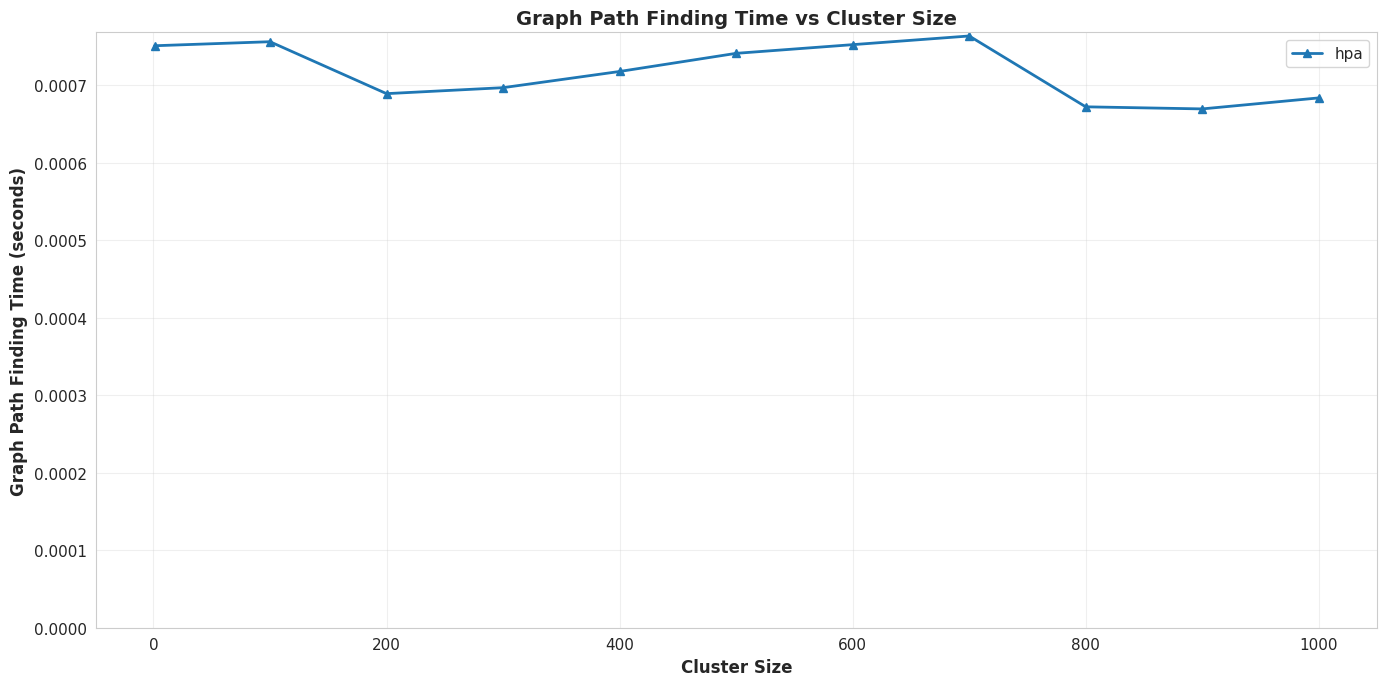

Plot: Graph path time vs cluster size


In [14]:
if 'found_graph_path' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 7))
    
    for algo in sorted(df['algorithm'].unique()):
        algo_data = df[df['algorithm'] == algo]
        grouped = algo_data.groupby('cluster_size')['found_graph_path'].agg(['mean'])
        
        ax.plot(grouped.index, grouped['mean'], 
                   marker='^', label=algo, linewidth=2, markersize=6)
    
    ax.set_xlabel('Cluster Size', fontsize=12, fontweight='bold')
    ax.set_ylabel('Graph Path Finding Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_title('Graph Path Finding Time vs Cluster Size', fontsize=14, fontweight='bold')
    ax.set_ylim([0, None])
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("Plot: Graph path time vs cluster size")

## Graph Path Time vs Cluster Size

Compare graph path finding time across algorithms.

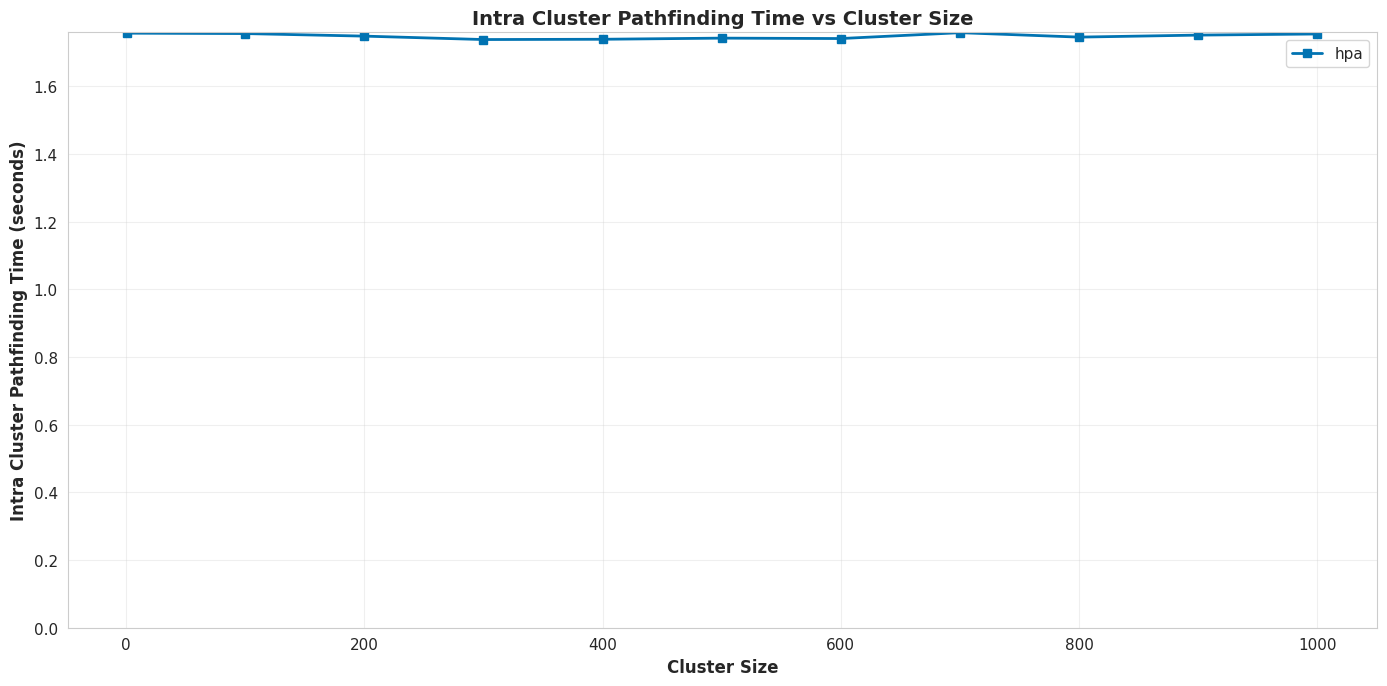

Plot: Intra cluster pathfinding time vs cluster size


In [110]:
if 'intra cluster pathfinding' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 7))
    
    for algo in sorted(df['algorithm'].unique()):
        algo_data = df[df['algorithm'] == algo]
        grouped = algo_data.groupby('cluster_size')['intra cluster pathfinding'].agg(['mean'])
        
        ax.plot(grouped.index, grouped['mean'], 
                   marker='s', label=algo, linewidth=2, markersize=6)
    
    ax.set_xlabel('Cluster Size', fontsize=12, fontweight='bold')
    ax.set_ylabel('Intra Cluster Pathfinding Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_title('Intra Cluster Pathfinding Time vs Cluster Size', fontsize=14, fontweight='bold')
    ax.set_ylim([0, None])
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("Plot: Intra cluster pathfinding time vs cluster size")

## Intra Cluster Pathfinding Time vs Cluster Size

Analyze intra cluster pathfinding costs for each algorithm.

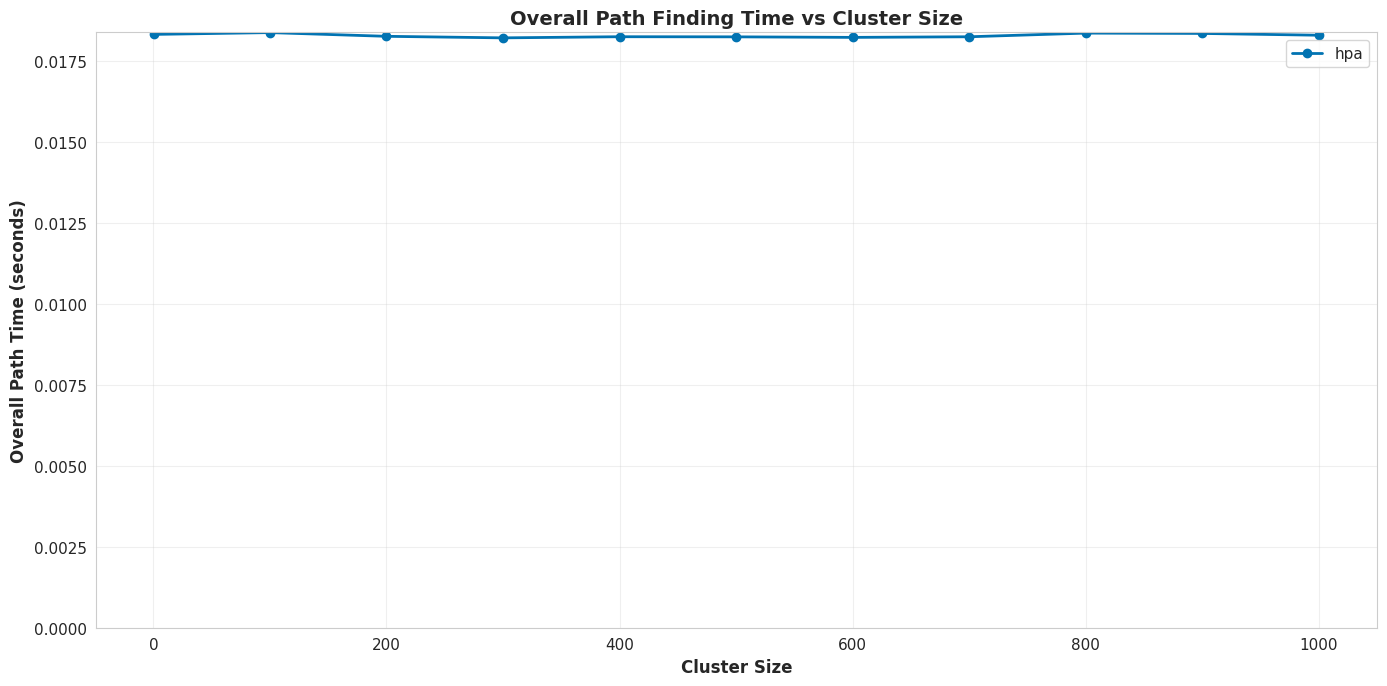

Plot: Overall path time vs cluster size


In [109]:
if 'found_overall_path' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 7))
    
    for algo in sorted(df['algorithm'].unique()):
        algo_data = df[df['algorithm'] == algo]
        grouped = algo_data.groupby('cluster_size')['found_overall_path'].agg(['mean'])
        
        ax.plot(grouped.index, grouped['mean'], 
                   marker='o', label=algo, linewidth=2, markersize=6)
    
    ax.set_xlabel('Cluster Size', fontsize=12, fontweight='bold')
    ax.set_ylabel('Overall Path Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_title('Overall Path Finding Time vs Cluster Size', fontsize=14, fontweight='bold')
    ax.set_ylim([0, None])
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("Plot: Overall path time vs cluster size")

## Overall Path Time vs Cluster Size

Plot the overall path finding time for each algorithm across different cluster sizes.

In [108]:
# Calculate statistics by cluster size and algorithm
# Focus on the overall path finding time as the main metric
timing_cols = [col for col in df.columns if col not in ['cluster_size', 'algorithm', 'run']]

stats_data = []
for cluster_size in sorted(df['cluster_size'].unique()):
    for algo in sorted(df['algorithm'].unique()):
        subset = df[(df['cluster_size'] == cluster_size) & (df['algorithm'] == algo)]
        
        if len(subset) > 0:
            row = {
                'cluster_size': cluster_size,
                'algorithm': algo,
                'n_runs': len(subset),
            }
            
            # Calculate stats for each timing metric
            for col in timing_cols:
                if col in subset.columns:
                    row[f'{col}_mean'] = subset[col].mean()
                    row[f'{col}_std'] = subset[col].std()
                    row[f'{col}_min'] = subset[col].min()
                    row[f'{col}_max'] = subset[col].max()
            
            stats_data.append(row)

stats_df = pd.DataFrame(stats_data)
print("Statistics DataFrame created")
print(f"Shape: {stats_df.shape}")
print("\nSample statistics:")
print(stats_df.head(10))

Statistics DataFrame created
Shape: (11, 27)

Sample statistics:
   cluster_size algorithm  n_runs  found inter edges_mean  \
0             1       hpa      10                0.001597   
1           100       hpa      10                0.001562   
2           200       hpa      10                0.001569   
3           300       hpa      10                0.001602   
4           400       hpa      10                0.001563   
5           500       hpa      10                0.001654   
6           600       hpa      10                0.001550   
7           700       hpa      10                0.001561   
8           800       hpa      10                0.001551   
9           900       hpa      10                0.001636   

   found inter edges_std  found inter edges_min  found inter edges_max  \
0               0.000067               0.001538               0.001765   
1               0.000030               0.001541               0.001634   
2               0.000054               0.

## Calculate Statistics

Calculate mean, standard deviation, and other statistics for each algorithm and cluster size.

In [107]:
# Convert results to DataFrame
data_rows = []

for point in results['data']:
    row = {
        'cluster_size': point['cluster_size'],
        'algorithm': point['algorithm'],
        'run': point['run'],
    }
    # Add all timing metrics
    row.update(point['timings'])
    data_rows.append(row)

df = pd.DataFrame(data_rows)

# Rename columns for clarity
rename_mapping = {
    'preprocessed': 'intra cluster pathfinding',
    'inter_edges': 'found inter edges'
}
# Only rename columns that exist
rename_mapping = {old: new for old, new in rename_mapping.items() if old in df.columns}
df = df.rename(columns=rename_mapping)

# Display basic info
print("DataFrame shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nAlgorithms:", df['algorithm'].unique())
print("Cluster sizes:", sorted(df['cluster_size'].unique()))

DataFrame shape: (110, 9)

Column names:
['cluster_size', 'algorithm', 'run', 'found inter edges', 'intra cluster pathfinding', 'finish_abstract_graph', 'found_graph_path', 'found_overall_path', 'max_memory']

First few rows:
   cluster_size algorithm  run  found inter edges  intra cluster pathfinding  \
0             1       hpa    1           0.001765                   1.781711   
1             1       hpa    2           0.001617                   1.769228   
2             1       hpa    3           0.001620                   1.756592   
3             1       hpa    4           0.001598                   1.766622   
4             1       hpa    5           0.001551                   1.746591   

   finish_abstract_graph  found_graph_path  found_overall_path  max_memory  
0               0.005469          0.000180            0.018325        3.24  
1               0.005576          0.000172            0.018905        3.21  
2               0.005639          0.000215            0.018305

## Parse and Organize Data

Convert benchmark data into a structured DataFrame for analysis.

In [106]:
# Load benchmark results
results_file = Path("benchmark_results.json")

if not results_file.exists():
    print(f"Error: {results_file} not found. Please run benchmark.py first.")
    print("Usage: python3 benchmark.py")
else:
    with open(results_file, "r") as f:
        results = json.load(f)
    
    print(f"Loaded benchmark data from {results_file}")
    print(f"Timestamp: {results['metadata']['timestamp']}")
    print(f"Cluster sizes: {results['metadata']['cluster_sizes']}")
    print(f"Algorithms: {results['metadata']['algorithms']}")
    print(f"Runs per size: {results['metadata']['runs_per_size']}")
    print(f"Total data points: {len(results['data'])}")

Loaded benchmark data from benchmark_results.json
Timestamp: 2026-05-11T12:08:16.948552
Cluster sizes: [1, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
Algorithms: ['hpa']
Runs per size: 10
Total data points: 110


## Load Benchmark Data

Load the results from the benchmark JSON file.

In [105]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set style for better-looking plots with colorblind-friendly palette
sns.set_style("whitegrid")
sns.set_palette("colorblind")  # Colorblind-friendly palette
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

## Import Required Libraries

Import necessary libraries for data analysis and visualization.

**Note:** This notebook uses colorblind-friendly color palettes and colormaps to ensure accessibility for users with color vision deficiency (CVD). All visualizations are designed to be clear and distinguishable for individuals with protanopia, deuteranopia, and tritanopia.

# Pathfinding Algorithm Benchmark Analysis

Analysis and visualization of benchmark results for A*, HPA*, and other pathfinding algorithms across varying cluster sizes.